# Youtube Comment Sentiment Analysis

# Citation
Amaan Poonawala (2025). YouTube Comment Sentiment Dataset (1M+ labeled comments) [Data set]. Hugging Face. https://huggingface.co/datasets/AmaanP314/youtube-comment-sentiment

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textwrap import wrap

import regex as re
import spacy
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, 
    accuracy_score, precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Embedding, LSTM


# Reading in the file and initial checks

In [2]:
df = pd.read_csv("hf://datasets/AmaanP314/youtube-comment-sentiment/youtube-comments-sentiment.csv")

D:\Anaconda\envs\InstituteOfData\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df.head()

,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,UgyRjrEdJIPrf68uND14AaABAg,mcY4M9gjtsI,They killed my friend.#tales #movie #shorts,@OneWhoWandered,UC_-UEXaBL1dqqUPGkDll49A,Anyone know what movie this is?,Neutral,0,2,2025-01-15 00:54:55,NZ,1
1,UgxXxEIySAwnMNw8D7N4AaABAg,2vuXcw9SZbA,Man Utd conceding first penalty at home in yea...,@chiefvon3068,UCZ1LcZESjYqzaQRhjdZJFwg,The fact they're holding each other back while...,Positive,0,0,2025-01-13 23:51:46,AU,17
2,UgxB0jh2Ur41mcXr5IB4AaABAg,papg2tsoFzg,Welcome to Javascript Course,@Abdulla-ip8qr,UCWBK35w5Swy1iF5xIbEyw3A,waiting next video will be?,Neutral,1,0,2020-07-06 13:18:16,IN,27
3,UgwMOh95MfK0GuXLLrF4AaABAg,31KTdfRH6nY,Building web applications in Java with Spring ...,@finnianthehuman,UCwQ2Z03nOcMxWozBb_Cv66w,Thanks for the great video.\n\nI don't underst...,Neutral,0,1,2024-09-18 12:04:12,US,27
4,UgxJuUe5ysG8OSbABAl4AaABAg,-hV6aeyPHPA,After a new engine her car dies on her way hom...,@ryoutubeplaylistb6137,UCTTcJ0tsAKQokmHB2qVb1qQ,Good person helping good people.\nThis is how ...,Positive,3,1,2025-01-10 19:39:03,US,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032225 entries, 0 to 1032224
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   CommentID        1032225 non-null  object
 1   VideoID          1032225 non-null  object
 2   VideoTitle       1032225 non-null  object
 3   AuthorName       1031594 non-null  object
 4   AuthorChannelID  1032225 non-null  object
 5   CommentText      1032225 non-null  object
 6   Sentiment        1032225 non-null  object
 7   Likes            1032225 non-null  int64 
 8   Replies          1032225 non-null  int64 
 9   PublishedAt      1032225 non-null  object
 10  CountryCode      1032225 non-null  object
 11  CategoryID       1032225 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 94.5+ MB


# Exploring the data

In [5]:
df['Sentiment'].value_counts(normalize=True)

Sentiment
Negative    0.335271
Positive    0.332599
Neutral     0.332130
Name: proportion, dtype: float64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.sort_values('Likes',ascending=False)

,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
3196,UgywVJlNM7Z4los9oJR4AaABAg,vWbfZEO6_VY,Can’t take away medical dogs!#shorts #viralvid...,@jonlanier_,UCRoJdq6OzSReWQ07lRppiFg,All she had to do was run another 20 yards and...,Negative,275849,720,2024-12-24 06:54:22,NZ,15
831720,UgxeR_hvgzdNbccKEs94AaABAg,myjEoDypUD8,Watch the uncensored moment Will Smith smacks ...,@BrentTV,UC2C6_mSbiLp3CplZcgLTHXg,This makes me regret not watching this on live...,Neutral,217740,408,2022-03-28 04:08:43,GB,25
476106,Ugz13n2V7JlWYZMG8ct4AaABAg,Rwud_h6dZg4,Dr. House’s teaching style is amazing #movie #...,@lord_haven1114,UCO7avuean26ua8wlUWyHs2g,House thinking “god every one of you would hav...,Neutral,201768,80,2025-01-09 02:49:22,AU,24
589511,Ugxek6FZtO_2nZAx89d4AaABAg,vWbfZEO6_VY,Can’t take away medical dogs!#shorts #viralvid...,@royalcupcake4243,UC5_VfVt7nSs7ECYzx8zcy4g,Amazing thing about service dogs is that they ...,Positive,193734,575,2024-12-22 13:46:57,NZ,15
395809,Ugxg0lIO9C-ilKNIyFN4AaABAg,38H90lgkZdk,Never Mess With Eddie Hall🥶(@worldfreakfightle...,@smdsnowflakes5107,UCMWuyuRlLEWk3NxoGYR_ywA,It's like Hulk fighting 2 chihuahuas😂,Positive,183754,417,2025-01-09 13:49:06,AU,17
...,...,...,...,...,...,...,...,...,...,...,...,...
7,UgwuFh4s9cHu3dHrPqJ4AaABAg,sKniMxl9zwo,Trump’s Reaction During ‘Abuse of Power’ Says ...,@StaceyBrown-h6o,UCzTaRiUaLcaLD9I0l2tCBCA,Thank God we don’t have to listen to his drive...,Positive,0,0,2025-01-14 01:24:48,IE,25
8,UgwzYX76p4RK8AHVcYN4AaABAg,yUImrnDqGUk,Thank god this angel found this beautiful dog ...,@cassiegerst6123,UC-QvE5-ZberkWmSYDXLvfQA,Very similar thing happened to me! We lived ne...,Positive,0,0,2025-01-14 03:54:19,AU,15
9,UgzW7h-gmtmgIFFClLJ4AaABAg,5VPxcrvVkBc,He betrayed his own friend - Enjoying a cup of...,@josh_playz2709,UCflV1g1fmgs5i2QZwiaHT8g,im about to cry😢,Negative,0,0,2025-01-13 09:55:03,IE,20
11,UgzJHIMWZvO9VfFKMSx4AaABAg,0Da7hDTXXlw,They Got Our Boi @Gsxystunt #bikesvscops #bike...,@ToddDavis-p3u,UCXeIPneqTYkniC0ifYh1S9A,Big deal.,Neutral,0,0,2025-01-08 04:06:12,US,2


In [8]:
df['PublishedAt'] = pd.to_datetime(df['PublishedAt'])
df['Date'] = df['PublishedAt'].dt.date

In [9]:
print(f'The earliest comment is {df['Date'].min()}')
print(f'The latest comment is {df['Date'].max()}')
print(f'The top date is {df['Date'].value_counts().idxmax()}')

The earliest comment is 2013-04-05
The latest comment is 2025-02-05
The top date is 2025-01-12


# Sentiment Analysis

## Reducing the size of the dataset

In [10]:
#I want to use only ~10k rows instead of 1 million or 1% of data

#This applies a sampling function to a each sentiment group. Keeps only the comment and sentiment columns
df_10k = df[['CommentText', 'Sentiment']].groupby('Sentiment', group_keys=False).sample(frac=.01, random_state=42)
df_10k.head()

,CommentText,Sentiment
582862,My loop isn't stopping in VS Code.,Negative
794033,That's not even a hundred feet😂,Negative
231656,The people in Palisades didn’t sit around and ...,Negative
517045,"God,I know the reporter is stressed but she ca...",Negative
992492,Gavin Newsom and Karen Bass the Trudeau's of C...,Negative


In [11]:
df_10k.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10322 entries, 582862 to 720907
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CommentText  10322 non-null  object
 1   Sentiment    10322 non-null  object
dtypes: object(2)
memory usage: 241.9+ KB


In [12]:
df_10k[df_10k['Sentiment'] == 'Negative'].sample(1)

,CommentText,Sentiment
706061,Mushrooms are for people that have no joy in l...,Negative


In [13]:
df_10k[df_10k['Sentiment'] == 'Neutral'].sample(1)

,CommentText,Sentiment
320509,He loves his 8 1/2 foot probe,Neutral


In [14]:
df_10k[df_10k['Sentiment'] == 'Positive'].sample(1)['CommentText']

708352    Lekcja kultury dla przybysza .
Name: CommentText, dtype: object

In [15]:
#Checks if it keeps the same ratio
df_10k["Sentiment"].value_counts(normalize=True)

Sentiment
Negative    0.335303
Positive    0.332591
Neutral     0.332106
Name: proportion, dtype: float64

In [16]:
df_10k["Sentiment"] = df_10k["Sentiment"].map({'Negative':0, 'Neutral': 1, 'Positive':2})

In [17]:
#No empty comments
df_10k[df_10k['CommentText'] == ""]

,CommentText,Sentiment


## Text Preprocessing for EDA

In [18]:
nlp = spacy.load('en_core_web_sm')

In [19]:
#Standardization and Tokenization for EDA
#Removing the punctuation, capitalization, digits and stopwords for the EDA.
#Not used for the model

def eda_standardize_tokenize_text(text):
    '''
    This function will use spacy to tokenize the text 
    and remove punctuation, capitalization, digits, and stopwords.
    '''

    #Tokenize as well as lowercase everything 
    doc = nlp(str(text).lower())

    #To hold the tokens that are standardized
    cleaned_text = []

    for token in doc:
        #If not stop word, punctuation, or digit
        if not token.is_stop and not token.is_punct and not token.like_num:
            # Add to our clean text list
            cleaned_text.append(token.text)

    #Join the words back together and return it
    return " ".join(cleaned_text)

In [20]:
df_10k_eda = df_10k.copy()

In [21]:
df_10k_eda["CleanedText"] = df_10k_eda['CommentText'].apply(eda_standardize_tokenize_text)

In [22]:
df_10k_eda.head()

,CommentText,Sentiment,CleanedText
582862,My loop isn't stopping in VS Code.,0,loop stopping vs code
794033,That's not even a hundred feet😂,0,feet 😂
231656,The people in Palisades didn’t sit around and ...,0,people palisades sit wait leave like said bloc...
517045,"God,I know the reporter is stressed but she ca...",0,god know reporter stressed barley coherent sen...
992492,Gavin Newsom and Karen Bass the Trudeau's of C...,0,gavin newsom karen bass trudeau california


Now that we have clean text, we can do EDA on it

## EDA on comment text

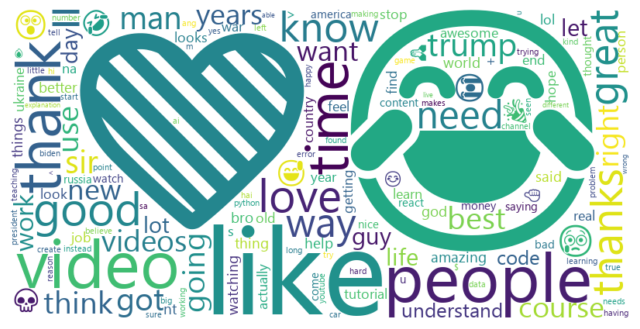

In [23]:
#Word cloud
word_counts = df_10k_eda['CleanedText'].str.split().explode().value_counts()

emoji_font_path = r"C:\Windows\Fonts\seguiemj.ttf"
word_counts_dict = word_counts.to_dict()
wordcloud = WordCloud(width=800, 
                      height=400, 
                      background_color='white',
                      max_words=150,
                      font_path=emoji_font_path,
                      colormap="viridis").generate_from_frequencies(word_counts_dict)
plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud.png",bbox_inches='tight', pad_inches=0)
plt.show()

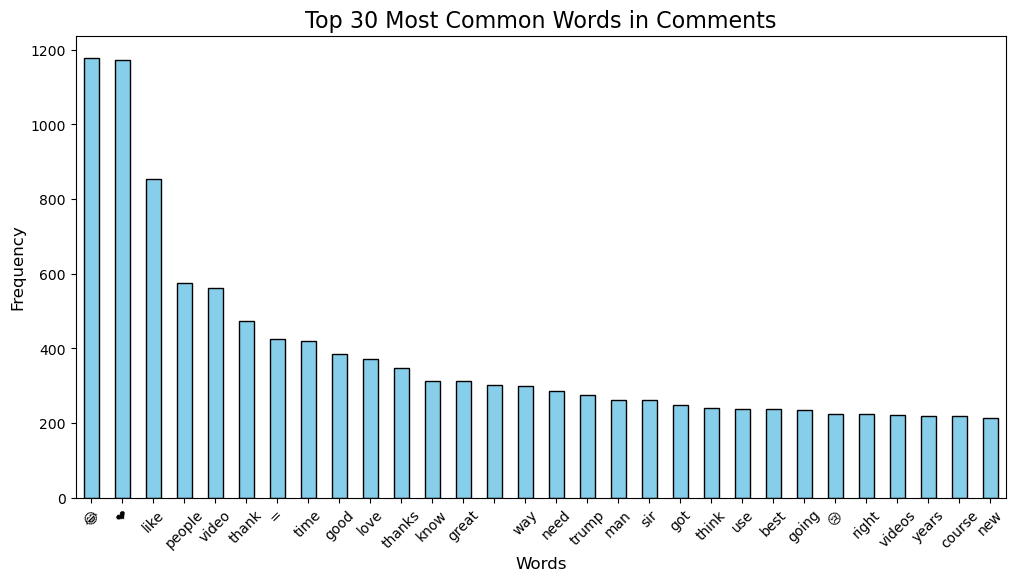

In [24]:
#Top 30 most common
top_30_words = word_counts.head(30)

plt.figure(figsize=(12, 6))
top_30_words.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 30 Most Common Words in Comments', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.savefig('BarChartMostCommonWords',bbox_inches='tight', pad_inches=0)
plt.show()

In [25]:
#Top 10 words negative and positive and neutral
df_negative = df_10k_eda[df_10k_eda['Sentiment'] == 0]
df_neutral = df_10k_eda[df_10k_eda['Sentiment'] == 1]
df_positive = df_10k_eda[df_10k_eda['Sentiment'] == 2]

words_negative = df_negative['CleanedText'].str.split().explode().value_counts()
words_neutral = df_neutral['CleanedText'].str.split().explode().value_counts()
words_positive = df_positive['CleanedText'].str.split().explode().value_counts()

In [26]:
df_negative.iloc[0].str.split()

CommentText    [My, loop, isn't, stopping, in, VS, Code.]
Sentiment                                             NaN
CleanedText                    [loop, stopping, vs, code]
Name: 582862, dtype: object

In [27]:
df_10k_eda['WordCount'] = df_10k_eda['CommentText'].str.split().str.len()
df_10k_eda

,CommentText,Sentiment,CleanedText,WordCount
582862,My loop isn't stopping in VS Code.,0,loop stopping vs code,7
794033,That's not even a hundred feet😂,0,feet 😂,6
231656,The people in Palisades didn’t sit around and ...,0,people palisades sit wait leave like said bloc...,57
517045,"God,I know the reporter is stressed but she ca...",0,god know reporter stressed barley coherent sen...,15
992492,Gavin Newsom and Karen Bass the Trudeau's of C...,0,gavin newsom karen bass trudeau california,9
...,...,...,...,...
273349,I love c++.\nIt's amazing,2,love c++ \n amazing,5
672583,Amazing & Cool.,2,amazing cool,3
420513,game conquerer,2,game conquerer,2
134842,That Dem Senator got an education while we all...,2,dem senator got education laughed,12


In [28]:
print(df_10k_eda.groupby('Sentiment')['WordCount'].mean())

Sentiment
0    23.884715
1    16.534714
2    18.812700
Name: WordCount, dtype: float64


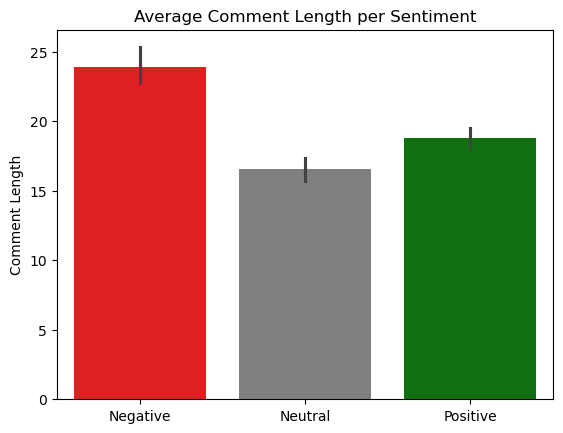

In [29]:
sns.barplot(
    data=df_10k_eda, 
    x="Sentiment", 
    y="WordCount", 
    hue="Sentiment", 
    palette=['red','gray','green'], 
    legend=False
)
plt.xticks(ticks=[0, 1, 2], labels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("")
plt.ylabel('Comment Length')
plt.title("Average Comment Length per Sentiment")
plt.savefig('avglen.png')
plt.show()

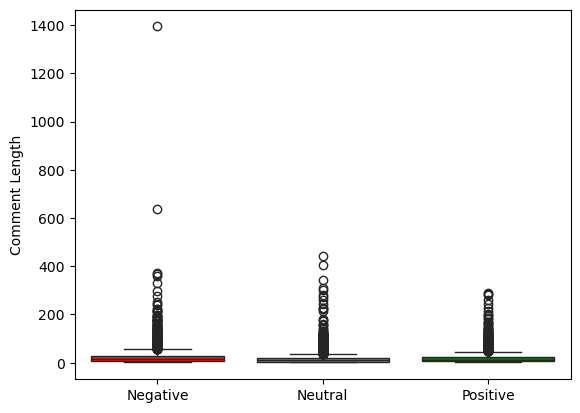

In [30]:
sns.boxplot(
    data=df_10k_eda, 
    x="Sentiment", 
    y="WordCount", 
    hue="Sentiment", 
    palette=['red','gray','green'], 
    legend=False
)
plt.xticks(ticks=[0, 1, 2], labels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("")
plt.ylabel('Comment Length')
plt.show()

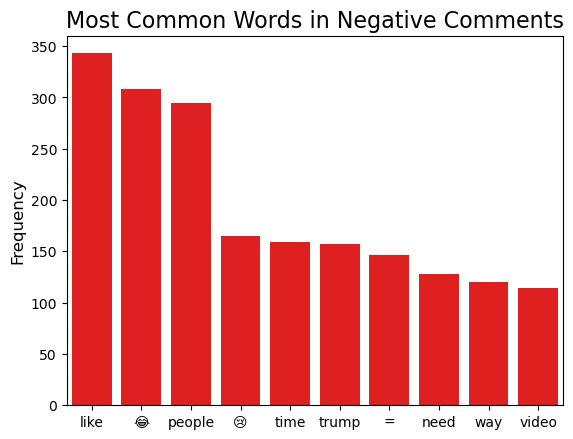

In [31]:
sns.barplot(words_negative.head(10),color="red")
plt.title('Most Common Words in Negative Comments', fontsize=16)
plt.xlabel('', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.savefig("topnegativewords.png")
plt.show()

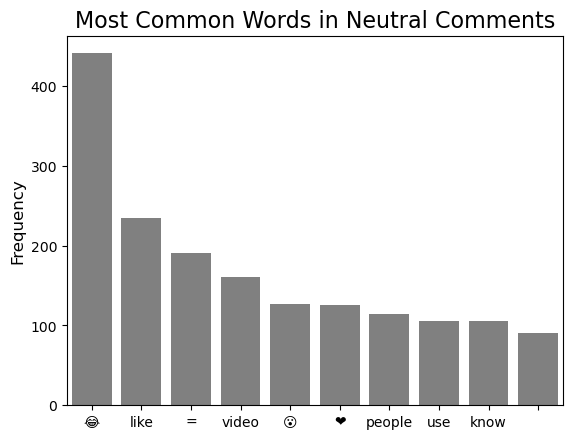

In [32]:
sns.barplot(words_neutral.head(10),color='gray')
plt.title('Most Common Words in Neutral Comments', fontsize=16)
plt.xlabel('')
plt.ylabel('Frequency', fontsize=12)
plt.savefig("topneutralwords.png")
plt.show()

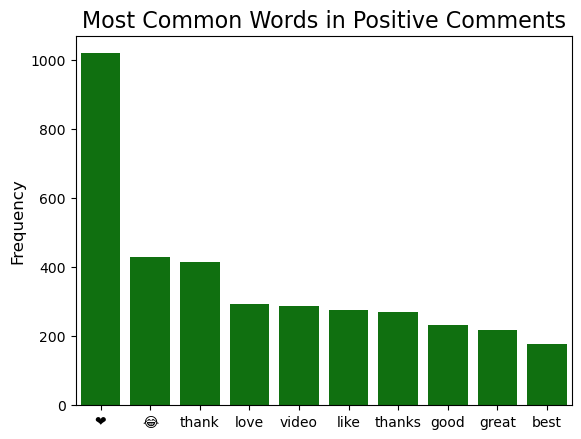

In [33]:
sns.barplot(words_positive.head(10),color="Green")
plt.title('Most Common Words in Positive Comments', fontsize=16)
plt.xlabel('')
plt.ylabel('Frequency', fontsize=12)
plt.savefig("toppositivewords.png")
plt.show()

## Text Preprocessing for the Models

In [34]:
#Standardization and Tokenization for actual models
#Didn't want to remove stopwords because they could be indicative of the sentiment\
#Similar to the EDA but no stopword and digit removal.
#Performs better than text without stopwords.

def standardize_tokenize_text(text):
    '''
    Cleans text by lowercasing, removing punctuation, and lemmatizing.
    Does NOT remove stopwords.
    '''
    #Lowercase and tokenize
    doc = nlp(text.lower())

    #To store the cleaned tokens
    cleaned_text = []
    
    for token in doc:
        # Skip empty spaces
        if token.is_space:
            continue

        #Remove Punctuation
        if token.is_punct:
            continue

        #Lemmatization    
        cleaned_text.append(token.lemma_)

    # Join the words back together and return it
    return " ".join(cleaned_text)

In [35]:
df_10k["CleanedText"] = df_10k['CommentText'].apply(standardize_tokenize_text)

## Splitting the dataset

In [36]:
df_10k.head()

,CommentText,Sentiment,CleanedText
582862,My loop isn't stopping in VS Code.,0,my loop be not stop in vs code
794033,That's not even a hundred feet😂,0,that be not even a hundred foot 😂
231656,The people in Palisades didn’t sit around and ...,0,the people in palisade do not sit around and w...
517045,"God,I know the reporter is stressed but she ca...",0,god I know the reporter be stress but she can ...
992492,Gavin Newsom and Karen Bass the Trudeau's of C...,0,gavin newsom and karen bass the trudeau 's of ...


In [37]:
X = df_10k['CleanedText']
y = df_10k['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

In [38]:
X_train.shape

(8257,)

In [39]:
y_train.value_counts(normalize=True)

Sentiment
0    0.335352
2    0.334383
1    0.330265
Name: proportion, dtype: float64

## Vectorization

### Base/Unigram TFIDF

In [40]:
tfidf = TfidfVectorizer(max_features=5000)

In [41]:
vec_xtrain = tfidf.fit_transform(X_train,y_train)
vec_xtrain.shape

(8257, 5000)

In [42]:
vec_xtest = tfidf.transform(X_test)
vec_xtest.shape

(2065, 5000)

### Bigram

In [43]:
tfidf_bi = TfidfVectorizer(max_features=10000,ngram_range=(1,2))
vec_xtrain_bi = tfidf_bi.fit_transform(X_train,y_train)
vec_xtest_bi = tfidf_bi.transform(X_test)

In [44]:
vec_xtrain.shape

(8257, 5000)

In [45]:
vec_xtest_bi.shape

(2065, 10000)

## Training models

### Base Models


In [46]:
#Base Models
log = LogisticRegression(max_iter=1000, random_state=42, C=0.01)
svc = SVC(random_state=42,C=.4)
rf = RandomForestClassifier(random_state=42,max_depth=10)

In [47]:
log.fit(vec_xtrain,y_train)
log_preds = log.predict(vec_xtest)

In [48]:
svc.fit(vec_xtrain,y_train)
svc_preds = svc.predict(vec_xtest)

In [49]:
rf.fit(vec_xtrain,y_train)
rf_preds = rf.predict(vec_xtest)

### Bigram

In [50]:
log_bi = LogisticRegression(max_iter=1000, random_state=42, C=0.01)
svc_bi = SVC(random_state=42,C=.4)
rf_bi = RandomForestClassifier(random_state=42,max_depth=10)

In [51]:
log_bi.fit(vec_xtrain_bi,y_train)
log_preds_bi = log_bi.predict(vec_xtest_bi)

In [52]:
svc_bi.fit(vec_xtrain_bi,y_train)
svc_preds_bi = svc_bi.predict(vec_xtest_bi)

In [53]:
rf_bi.fit(vec_xtrain_bi,y_train)
rf_preds_bi = rf_bi.predict(vec_xtest_bi)

## Evaluating the models

In [54]:
#For comparing later
results = []

In [55]:
#Helper function for evaluating models

def evaluate_model(y_test, pred, model, model_name, x_train, target_names=['Negative','Neutral','Positive']):
    #Classification Report
    print("\nClassification Report:\n", classification_report(y_test, pred,target_names=target_names))
    
    #Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        display_labels=target_names
    )
    plt.savefig(f'cm_{model_name}.png')
    plt.show()
    
    
    #Save results to the result list
    results.append({
        "Model": model_name,
        "Training Accuracy": model.score(x_train,y_train),
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Precision": precision_score(y_test, pred,average='weighted'),
        "Test Recall": recall_score(y_test, pred,average='weighted'),
        "Test F1_score": f1_score(y_test, pred,average='weighted')
    })


Classification Report:
               precision    recall  f1-score   support

    Negative       0.54      0.64      0.58       692
     Neutral       0.52      0.53      0.52       701
    Positive       0.69      0.54      0.61       672

    accuracy                           0.57      2065
   macro avg       0.58      0.57      0.57      2065
weighted avg       0.58      0.57      0.57      2065



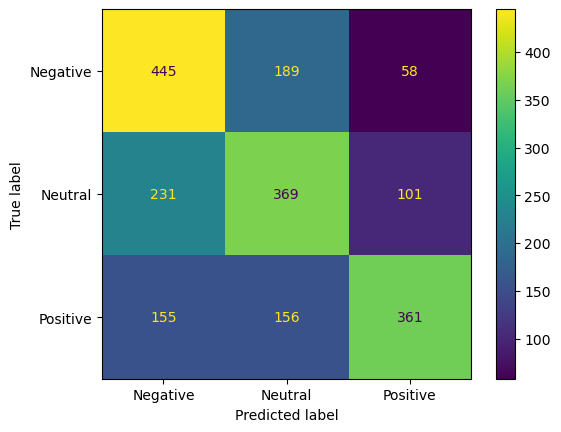

In [56]:
evaluate_model(y_test,log_preds,log, "Logistic Regression", vec_xtrain)


Classification Report:
               precision    recall  f1-score   support

    Negative       0.57      0.65      0.61       692
     Neutral       0.52      0.65      0.58       701
    Positive       0.82      0.47      0.60       672

    accuracy                           0.59      2065
   macro avg       0.64      0.59      0.59      2065
weighted avg       0.63      0.59      0.59      2065



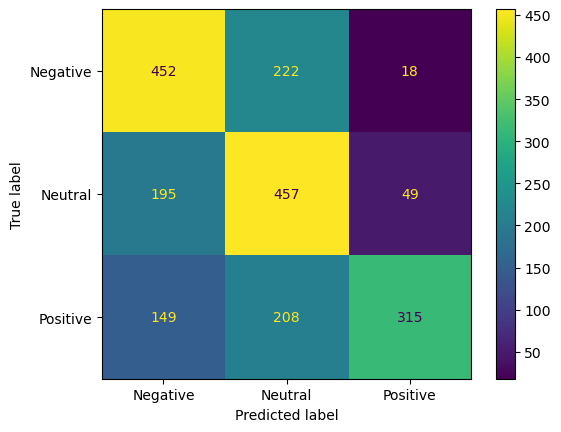

In [57]:
evaluate_model(y_test,svc_preds,svc, "Support Vector Machine", vec_xtrain)


Classification Report:
               precision    recall  f1-score   support

    Negative       0.54      0.59      0.56       692
     Neutral       0.49      0.58      0.53       701
    Positive       0.71      0.52      0.60       672

    accuracy                           0.56      2065
   macro avg       0.58      0.56      0.57      2065
weighted avg       0.58      0.56      0.57      2065



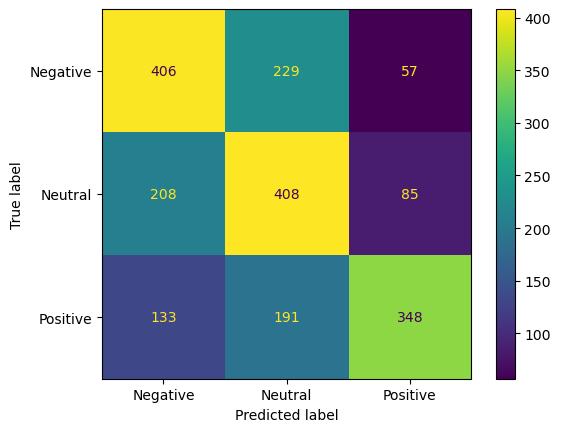

In [58]:
evaluate_model(y_test,rf_preds,rf, "Random Forest Classifier", vec_xtrain)


Classification Report:
               precision    recall  f1-score   support

    Negative       0.53      0.69      0.60       692
     Neutral       0.55      0.49      0.52       701
    Positive       0.69      0.55      0.61       672

    accuracy                           0.58      2065
   macro avg       0.59      0.58      0.58      2065
weighted avg       0.59      0.58      0.57      2065



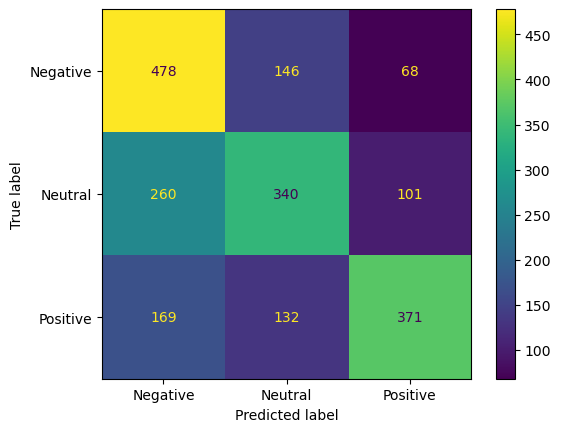

In [59]:
evaluate_model(y_test,log_preds_bi, log_bi, "Logistic Regression Bigram", vec_xtrain_bi)


Classification Report:
               precision    recall  f1-score   support

    Negative       0.56      0.68      0.61       692
     Neutral       0.53      0.64      0.58       701
    Positive       0.84      0.48      0.61       672

    accuracy                           0.60      2065
   macro avg       0.64      0.60      0.60      2065
weighted avg       0.64      0.60      0.60      2065



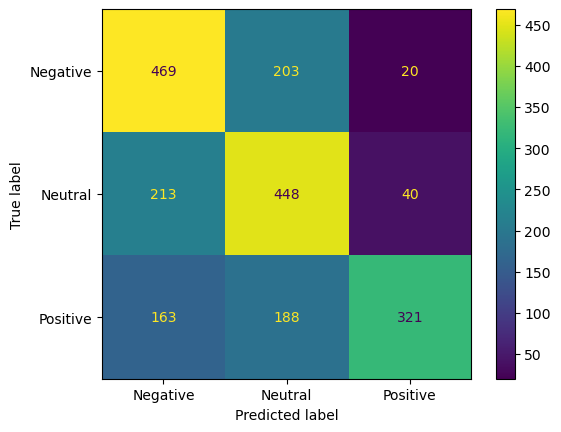

In [60]:
evaluate_model(y_test,svc_preds_bi,svc_bi, "Support Vector Machine Bigram", vec_xtrain_bi)


Classification Report:
               precision    recall  f1-score   support

    Negative       0.55      0.60      0.58       692
     Neutral       0.49      0.59      0.53       701
    Positive       0.73      0.51      0.60       672

    accuracy                           0.57      2065
   macro avg       0.59      0.57      0.57      2065
weighted avg       0.59      0.57      0.57      2065



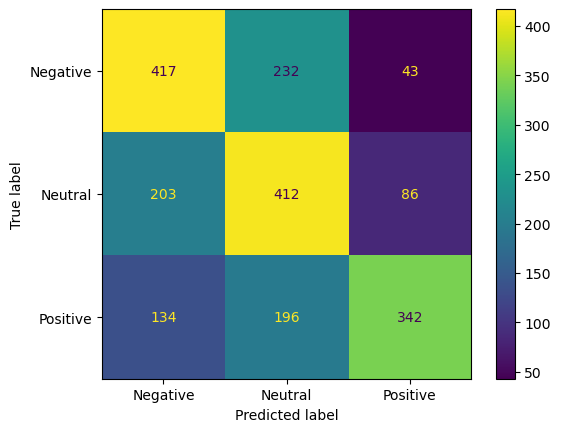

In [61]:
evaluate_model(y_test,rf_preds_bi,rf_bi, "Random Forest Classifier Bigram", vec_xtrain_bi)

In [62]:
pd.DataFrame(results)

,Model,Training Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1_score
0,Logistic Regression,0.570425,0.569007,0.580809,0.569007,0.569990
1,Support Vector Machine,0.765169,0.592736,0.633535,0.592736,0.593487
2,Random Forest Classifier,0.627952,0.562712,0.580525,0.562712,0.565181
3,Logistic Regression Bigram,0.598522,0.575787,0.586947,0.575787,0.574591
4,Support Vector Machine Bigram,0.789391,0.599516,0.641436,0.599516,0.600425
5,Random Forest Classifier Bigram,0.618263,0.567070,0.588128,0.567070,0.569540


## Using Embeddings

In [63]:
#Read in the downloaded glove file. 100d
glove_dict = {}
with open('glove.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        
        try:
            # Try to convert the remaining values to floats
            vector = np.asarray(values[1:], dtype='float32')
            glove_dict[word] = vector
        except ValueError:
            # If it hits the '.' bug or any other corrupted line, skip it!
            continue
print(f"Loaded {len(glove_dict)} word vectors successfully!")

Loaded 1287623 word vectors successfully!


In [64]:
#Vectorize the comment
def comment_to_vector(comment):
    # Split comment into words
    words = comment.lower().split()
    
    # Get the GloVe vector for each word (ignore words not in the dictionary)
    vectors = [glove_dict[word] for word in words if word in glove_dict and len(glove_dict[word]) == 100]

    #Gibberish or no comment
    if len(vectors) == 0:
        return np.zeros(100)
    
    # Average all the word vectors together
    return np.mean(vectors, axis=0)

# Apply this to your whole dataset
X_train_glove = np.array([comment_to_vector(comment) for comment in X_train])
X_test_glove = np.array([comment_to_vector(comment) for comment in X_test])

In [65]:
X_train_glove.shape

(8257, 100)

In [66]:
list(glove_dict.items())[:5]

[('the',
  array([ 0.306717, -0.32053 , -0.393647,  0.082826,  0.073522, -0.409154,
         -0.265564, -0.23694 , -0.305832,  0.74529 ,  0.214341,  0.276781,
         -0.152797, -0.127524,  0.119525,  0.640965, -0.175869,  0.160711,
          0.477978, -0.160939, -0.150093,  0.674601, -0.099565,  0.021882,
         -0.032771,  0.368641, -0.087019, -0.133326,  0.170143,  0.156934,
          0.677506, -0.099686,  0.392113,  0.373434, -5.736062,  0.413845,
          0.477368, -0.041697,  0.383109,  0.120152, -0.20947 ,  0.605104,
          0.236353,  0.151131, -0.508865,  0.671239, -0.300263, -0.267927,
          2.549487,  0.067177,  0.217224, -0.031316,  0.05231 ,  0.119321,
         -0.332154, -0.807904, -0.546453, -0.044392, -0.281657,  0.286647,
          0.325775, -0.02196 , -0.636903, -0.268063,  0.247956, -0.402493,
          0.276707, -0.275139,  0.201159,  0.082844,  0.591695, -0.017127,
         -0.092269,  0.392008,  0.078245, -0.049907,  0.235151,  0.457376,
         -0.1119

In [67]:
#Glove Models
log_glove = LogisticRegression(max_iter=1000, random_state=42)
svc_glove = SVC(random_state=42)
rf_glove = RandomForestClassifier(random_state=42,n_estimators = 100,max_depth=10,min_samples_split=5)

In [68]:
log_glove.fit(X_train_glove,y_train)
log_glove_preds = log_glove.predict(X_test_glove)

In [69]:
svc_glove.fit(X_train_glove,y_train)
svc_glove_preds = svc_glove.predict(X_test_glove)

In [70]:
rf_glove.fit(X_train_glove,y_train)
rf_glove_preds = rf_glove.predict(X_test_glove)


Classification Report:
               precision    recall  f1-score   support

    Negative       0.59      0.63      0.61       692
     Neutral       0.52      0.48      0.50       701
    Positive       0.61      0.63      0.62       672

    accuracy                           0.58      2065
   macro avg       0.58      0.58      0.58      2065
weighted avg       0.58      0.58      0.58      2065



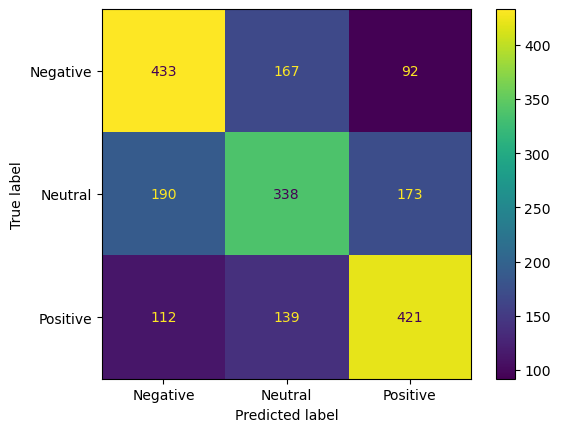

In [71]:
evaluate_model(y_test,log_glove_preds,log_glove, "Logistic Regression Glove", X_train_glove)


Classification Report:
               precision    recall  f1-score   support

    Negative       0.56      0.65      0.60       692
     Neutral       0.56      0.48      0.52       701
    Positive       0.62      0.62      0.62       672

    accuracy                           0.58      2065
   macro avg       0.58      0.58      0.58      2065
weighted avg       0.58      0.58      0.58      2065



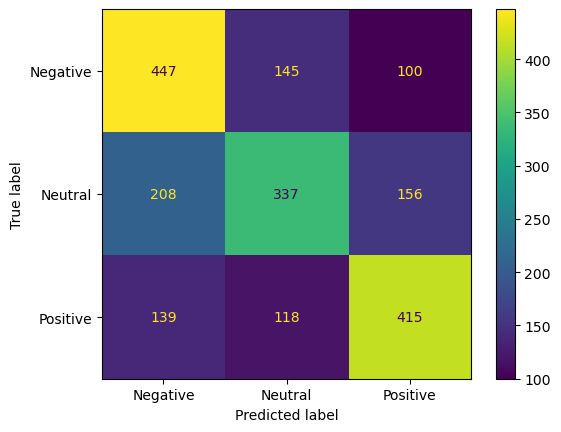

In [72]:
evaluate_model(y_test,svc_glove_preds,svc_glove, "Support Vector Machine Glove", X_train_glove)


Classification Report:
               precision    recall  f1-score   support

    Negative       0.56      0.65      0.60       692
     Neutral       0.55      0.47      0.51       701
    Positive       0.62      0.60      0.61       672

    accuracy                           0.57      2065
   macro avg       0.57      0.57      0.57      2065
weighted avg       0.57      0.57      0.57      2065



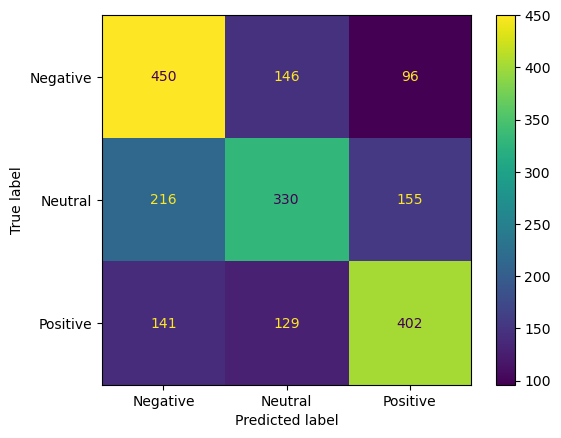

In [73]:
evaluate_model(y_test,rf_glove_preds,rf_glove, "Random Forest Glove", X_train_glove)

In [74]:
pd.DataFrame(results)

,Model,Training Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1_score
0,Logistic Regression,0.570425,0.569007,0.580809,0.569007,0.569990
1,Support Vector Machine,0.765169,0.592736,0.633535,0.592736,0.593487
2,Random Forest Classifier,0.627952,0.562712,0.580525,0.562712,0.565181
3,Logistic Regression Bigram,0.598522,0.575787,0.586947,0.575787,0.574591
4,Support Vector Machine Bigram,0.789391,0.599516,0.641436,0.599516,0.600425
5,Random Forest Classifier Bigram,0.618263,0.567070,0.588128,0.567070,0.569540
6,Logistic Regression Glove,0.588834,0.577240,0.575299,0.577240,0.575756
7,Support Vector Machine Glove,0.614388,0.580630,0.580593,0.580630,0.578590
8,Random Forest Glove,0.885915,0.572397,0.572365,0.572397,0.570217
